### HOT WHEELS SALES ANALYSIS 2025

In [2]:
pwd

'C:\\Users\\Admin\\PY-Project 2025'

In [3]:
cd ..

C:\Users\Admin


In [4]:
cd Downloads

C:\Users\Admin\Downloads


In [5]:
cd pro

C:\Users\Admin\Downloads\pro


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [7]:
df = pd.read_csv("hotwheels_cleaned.csv")
print("Rows, Columns:", df.shape)
display(df.head(101))
df.info()

Rows, Columns: (909, 11)


,Car_ID,Car_Name,Model_Year,Series,Country_Sold,Units_Sold,Price_USD,Age_Group_Buyers,Is_Banned,Manufacturing_Country,Rating
0,1192.0,BMW M3,1968.0,Limited Edition,Japan,477293.0,165.66,5-12,No,Indonesia,7.1
1,1295.0,Mustang GT,1968.0,Limited Edition,Japan,486133.0,92.90,5-12,No,Indonesia,6.6
2,63.0,BMW M3,1968.0,Limited Edition,UK,353832.0,108.95,25+,No,Malaysia,6.8
3,1512.0,Lamborghini Aventador,1968.0,Limited Edition,USA,475327.0,146.24,13-18,No,Malaysia,6.7
4,459.0,BMW M3,1968.0,Limited Edition,USA,159165.0,195.04,5-12,Yes,Thailand,7.1
...,...,...,...,...,...,...,...,...,...,...,...
96,109.0,Corvette Z06,1973.0,Treasure Hunt,Japan,499465.0,179.82,5-12,No,Thailand,7.3
97,593.0,Toyota Supra,1974.0,Mainline,Japan,383438.0,102.33,25+,No,Indonesia,6.8
98,1034.0,Mustang GT,1974.0,Mainline,UK,82648.0,290.60,19-25,No,Indonesia,7.8
99,1195.0,Corvette Z06,1974.0,Premium,Germany,402226.0,46.14,13-18,No,China,8.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Car_ID                 909 non-null    float64
 1   Car_Name               909 non-null    object 
 2   Model_Year             909 non-null    float64
 3   Series                 909 non-null    object 
 4   Country_Sold           909 non-null    object 
 5   Units_Sold             909 non-null    float64
 6   Price_USD              909 non-null    float64
 7   Age_Group_Buyers       909 non-null    object 
 8   Is_Banned              909 non-null    object 
 9   Manufacturing_Country  909 non-null    object 
 10  Rating                 909 non-null    float64
dtypes: float64(5), object(6)
memory usage: 78.2+ KB


In [17]:
df.columns

Index(['product_id', 'year', 'car_name', 'series', 'country',
       'manufacturer_country', 'units_sold', 'revenue_usd', 'buyer_age_group',
       'banned'],
      dtype='object')

In [13]:

# show missing counts
print("Missing values per column:\n", df.isnull().sum())

# remove exact duplicate rows
df.drop_duplicates(inplace=True)
print("After drop_duplicates:", df.shape)

Missing values per column:
 product_id              0
year                    0
car_name                0
series                  0
country                 0
manufacturer_country    0
units_sold              0
revenue_usd             0
buyer_age_group         0
banned                  0
dtype: int64
After drop_duplicates: (2500, 10)


###  4. Clean important columns (drop only truly broken rows; fill others sensibly)

In [9]:
# Keep rows that have essential values (Car_Name, Model_Year, Units_Sold)
df = df.dropna(subset=['Car_Name','Model_Year','Units_Sold']).copy()

# Convert Model_Year to integer (safe cast)
df['Model_Year'] = df['Model_Year'].astype(int)

# Fill common columns sensibly
df['Price_USD'] = df['Price_USD'].fillna(df['Price_USD'].median())          # numeric
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Age_Group_Buyers'] = df['Age_Group_Buyers'].fillna('Unknown')
df['Is_Banned'] = df['Is_Banned'].fillna('No')
df['Manufacturing_Country'] = df['Manufacturing_Country'].fillna('Unknown')
df['Series'] = df['Series'].fillna('Unknown')

# Verify
print("After cleaning:", df.shape)
print(df.isnull().sum())

After cleaning: (909, 11)
Car_ID                   0
Car_Name                 0
Model_Year               0
Series                   0
Country_Sold             0
Units_Sold               0
Price_USD                0
Age_Group_Buyers         0
Is_Banned                0
Manufacturing_Country    0
Rating                   0
dtype: int64


### 5 Top 10 models by units sold

In [10]:
top_models = df.groupby('Car_Name')['Units_Sold'].sum().nlargest(10)

# Total sales per year
yearly_sales = df.groupby('Model_Year')['Units_Sold'].sum()

# Top manufacturing countries
mfg_country_sales = df.groupby('Manufacturing_Country')['Units_Sold'].sum().nlargest(10)

# Banned cars summary
banned_summary = df[df['Is_Banned'] == 'Yes'].groupby('Car_Name')['Units_Sold'].sum()

### 6. TOP 5 MOST SOLD HOT WHEELS MODELS

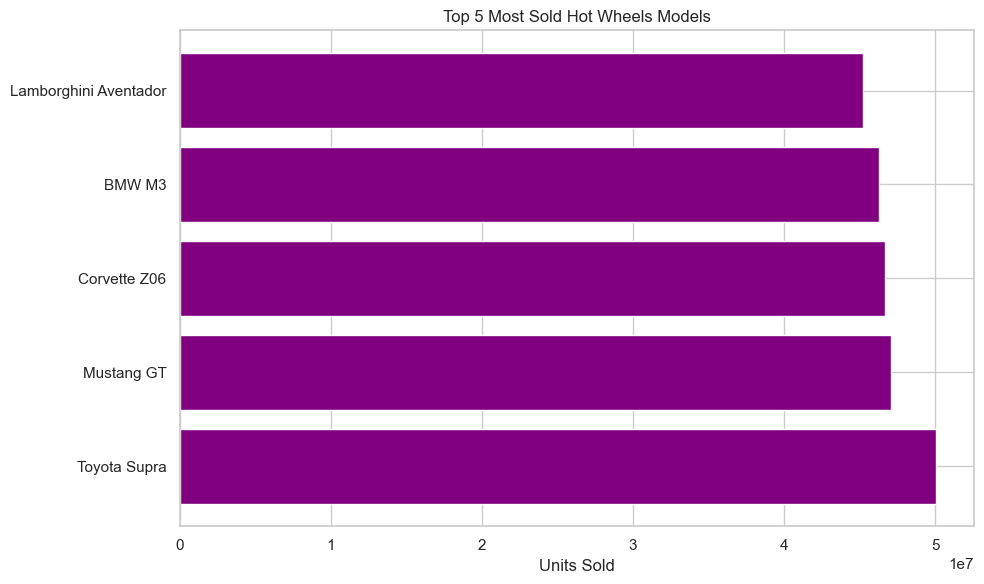

In [11]:
#6
top_models = df.groupby('Car_Name')['Units_Sold'].sum().nlargest(10)
plt.barh(top_models.index, top_models.values, color='purple')
plt.title('Top 5 Most Sold Hot Wheels Models')
plt.xlabel('Units Sold')
plt.tight_layout()
plt.show()

###  7.TOTAL SALES PER YEAR

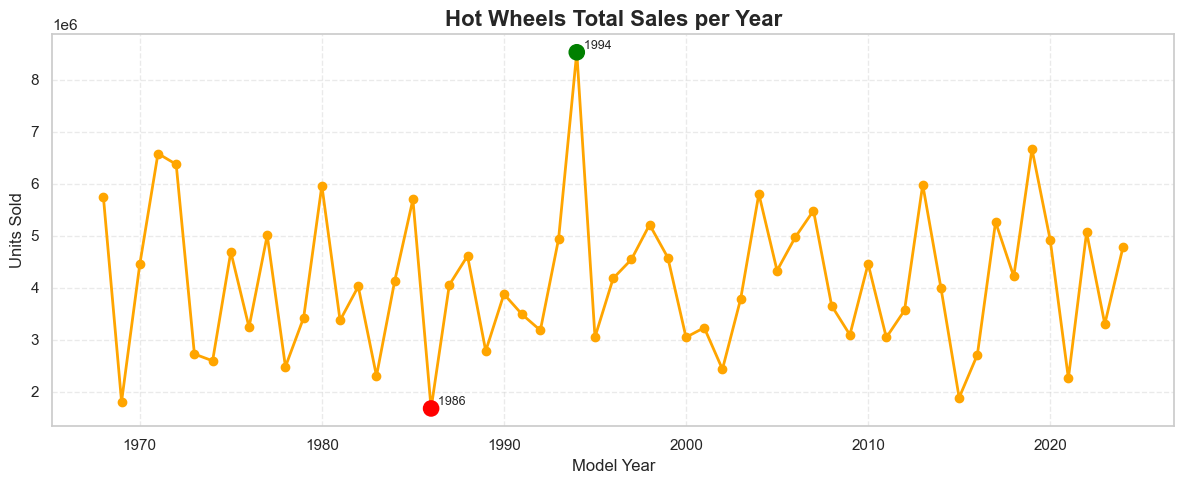

In [12]:
plt.figure(figsize=(12,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='orange', linewidth=2)
plt.title('Hot Wheels Total Sales per Year', fontsize=16, fontweight='bold')
plt.xlabel('Model Year'); plt.ylabel('Units Sold'); plt.grid(True, linestyle='--', alpha=0.4)

# highlight
max_year = yearly_sales.idxmax()
min_year = yearly_sales.idxmin()
plt.scatter([max_year, min_year], [yearly_sales[max_year], yearly_sales[min_year]], color=['green','red'], s=120, zorder=5)
plt.text(max_year, yearly_sales[max_year], f'  {max_year}', va='bottom', fontsize=9)
plt.text(min_year, yearly_sales[min_year], f'  {min_year}', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
#8
CLEAN_PATH = "hotwheels_dataset_cleaned.csv"
df.to_csv(CLEAN_PATH, index=False)
print("Saved cleaned dataset to", CLEAN_PATH)

Saved cleaned dataset to hotwheels_dataset_cleaned.csv


In [14]:
assert df['Model_Year'].dtype == int
assert df[['Car_Name','Units_Sold']].notnull().all().all()

In [15]:
series_counts = df['Series'].value_counts()

In [17]:
df_series = df['Series'].value_counts().reset_index()
df_series.columns = ['Series', 'Count']

### THE 4 SERIES 

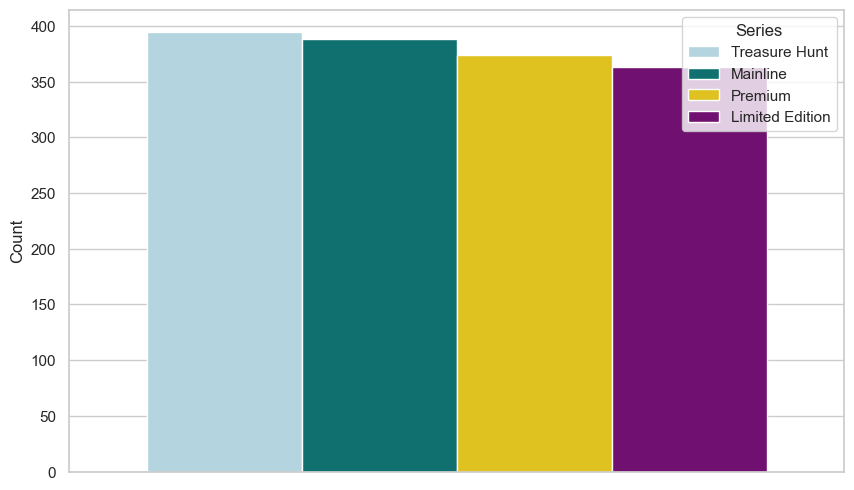

In [16]:
sns.barplot(data=df_series, hue="Series", y="Count",
            palette=["lightblue","teal","gold","purple"])
plt.show()

### Top 5 Manufacturing Countries by Units Sold

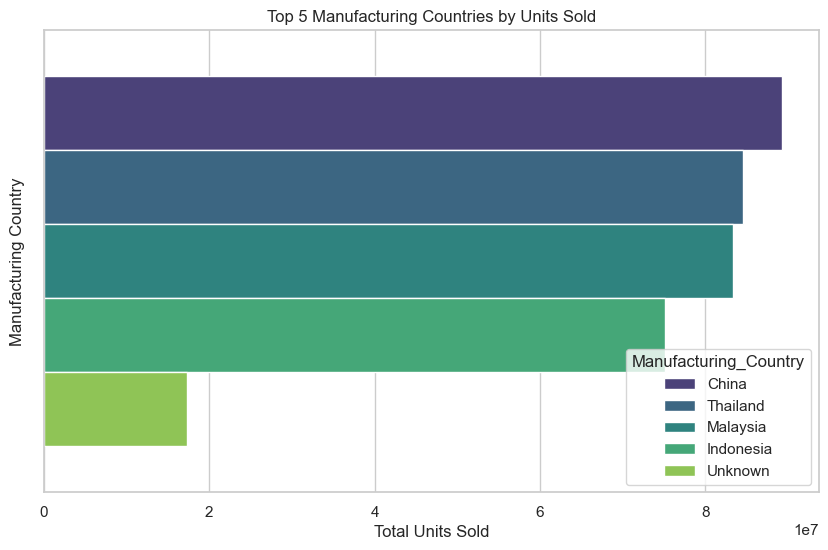

In [37]:
mfg_country_sales = df.groupby('Manufacturing_Country')['Units_Sold'].sum().sort_values(ascending=False).head(10)

# Plot bar chart
sns.barplot(x=mfg_country_sales.values, hue=mfg_country_sales.index, palette='viridis')
plt.title('Top 5 Manufacturing Countries by Units Sold')
plt.xlabel('Total Units Sold')
plt.ylabel('Manufacturing Country')
plt.show()

### Histogram — Distribution of Units Sold

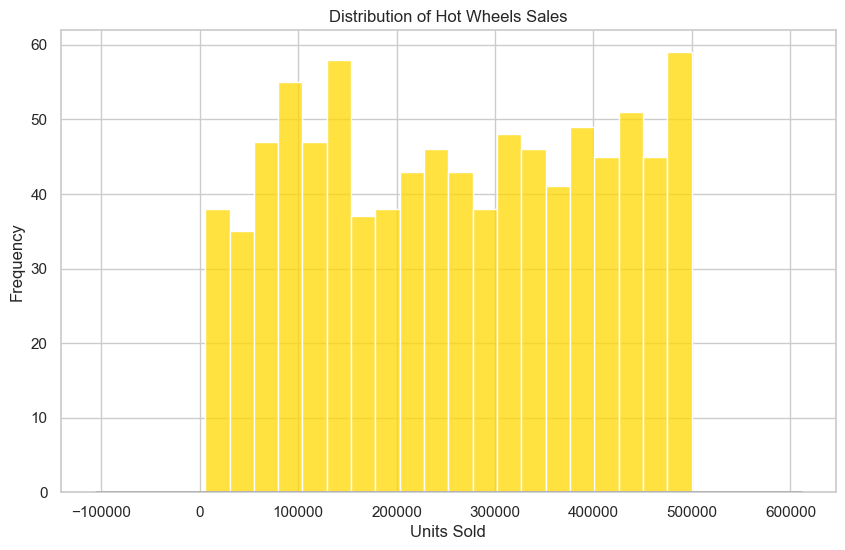

In [18]:
# Histogram
sns.histplot(df['Units_Sold'], bins=20, kde=False, color='gold')

# Black smooth curve (KDE)
sns.kdeplot(df['Units_Sold'], color='black', linewidth=2)

plt.title('Distribution of Hot Wheels Sales')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

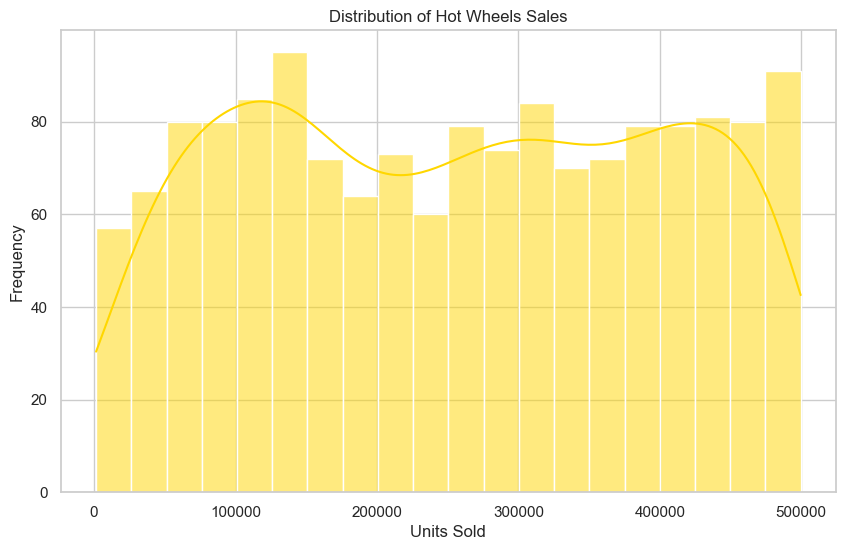

In [20]:
sns.histplot(df['Units_Sold'], bins=20, kde=True, color='gold')
plt.title('Distribution of Hot Wheels Sales')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

In [19]:
banned = df[df['Is_Banned'] == 'Yes']
banned.groupby('Car_Name')['Units_Sold'].sum().nlargest(10)

Car_Name
Toyota Supra             3120758.0
Mustang GT               2234872.0
Corvette Z06             2090171.0
BMW M3                   1487920.0
Lamborghini Aventador     640768.0
Name: Units_Sold, dtype: float64

### TOP 5 COUNTRIES BY SALES

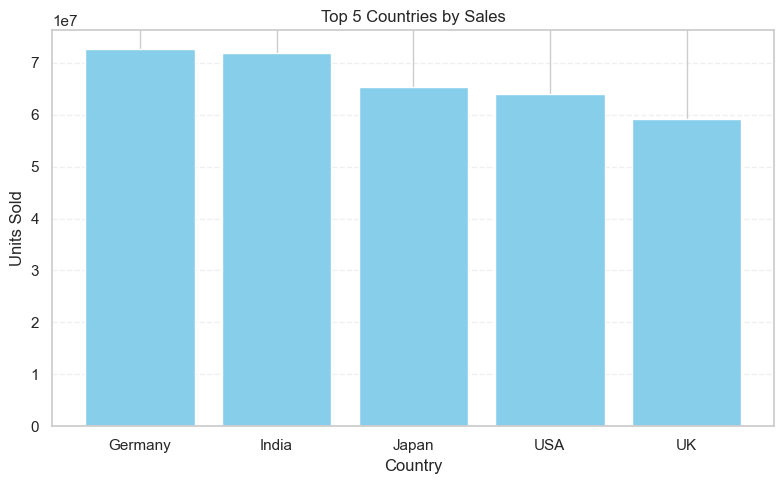

In [40]:
country_sales = df.groupby('Country_Sold')['Units_Sold'].sum().nlargest(5)

plt.figure(figsize=(8,5))
plt.bar(country_sales.index, country_sales.values, color="skyblue")

plt.title("Top 5 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Units Sold")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### CAR SALES WITH HEATMAP BY YEAR

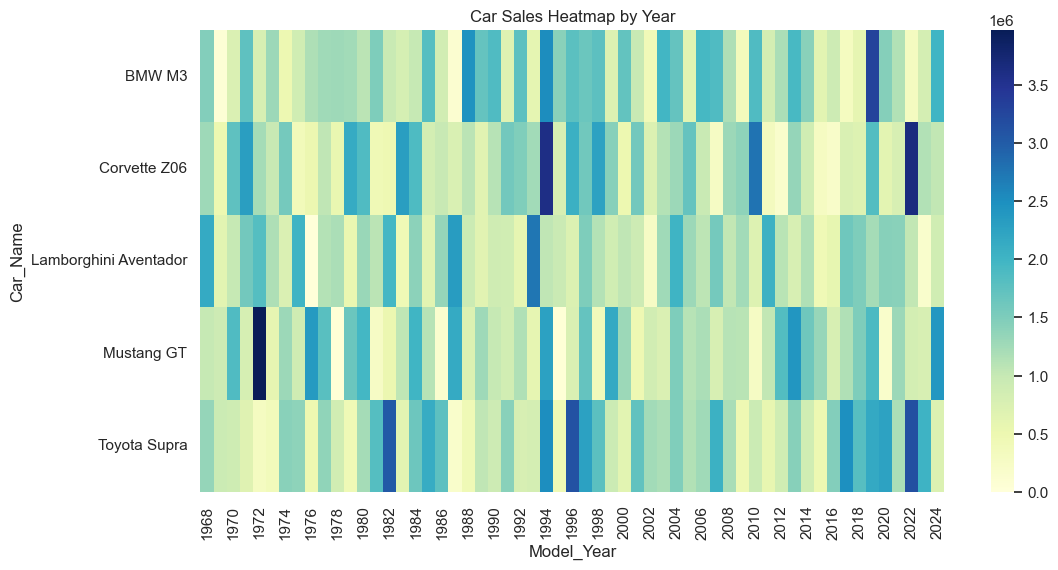

In [22]:
car_year_sales = df.pivot_table(
    values='Units_Sold',
    index='Car_Name',
    columns='Model_Year',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,6))
sns.heatmap(car_year_sales, cmap="YlGnBu")
plt.title("Car Sales Heatmap by Year")
plt.show()

### Summary: Hot Wheels Sales Analysis ###

   This project analyzes a dataset of 1,600 Hot Wheels car entries to understand sales patterns,
 model popularity, manufacturing trends, and global market performance. After cleaning missing and duplicate values, 
 the data was explored through several visualizations. The analysis identifies the top-selling car models, 
 the strongest manufacturing countries, and the top buyer markets. Yearly sales trends reveal fluctuations in demand, 
 while age-group and series distributions show consumer preferences. Additional insights include sales distribution patterns, 
 banned car statistics, and a heatmap showing long-term model performance across multiple years.

 Overall, the project provides a complete end-to-end understanding of how Hot Wheels perform globally — 
 across models, years, countries, and manufacturing origins.